# LLM-Augmented Stock Return Prediction
**AAPL · Next-Day Log Return · LSTM Comparison**

This notebook presents the full pipeline and results for a study comparing three LSTM conditions:

| Condition | Features |
|-----------|----------|
| **C1** — Baseline | OHLCV + technical indicators only |
| **C2** — LLM Embeddings | C1 + PCA-reduced sentence embeddings of LLM-generated news summaries |
| **C3** — LLM Predictor | C2 + LLM direction prediction + confidence score |

**Target variable:** next-day log return = log(close_t+1 / close_t) — predicting price *change*, not absolute price.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = {'C1': '#4C72B0', 'C2': '#DD8452', 'C3': '#55A868'}

---
## 1 · Data: AAPL Price History

In [2]:
prices = pd.read_csv('../data/processed/prices.csv', index_col='date', parse_dates=True)
print(f"{len(prices)} trading days  |  {prices.index.min().date()} → {prices.index.max().date()}")
prices[['close', 'ma5', 'ma20', 'daily_return', 'volatility20', 'target']].tail()

229 trading days  |  2025-05-13 → 2026-04-10


,close,ma5,ma20,daily_return,volatility20,target
date,,,,,,
2026-04-06,258.859985,254.165997,253.480499,0.011422,0.012574,-0.020923
2026-04-07,253.500000,255.539996,253.161499,-0.020923,0.013228,0.021078
2026-04-08,258.899994,256.561996,253.064999,0.021078,0.014112,0.006123
2026-04-09,260.489990,257.533994,253.048999,0.006123,0.014187,-0.000038
2026-04-10,260.480011,258.445996,253.285000,-0.000038,0.013426,-0.004926


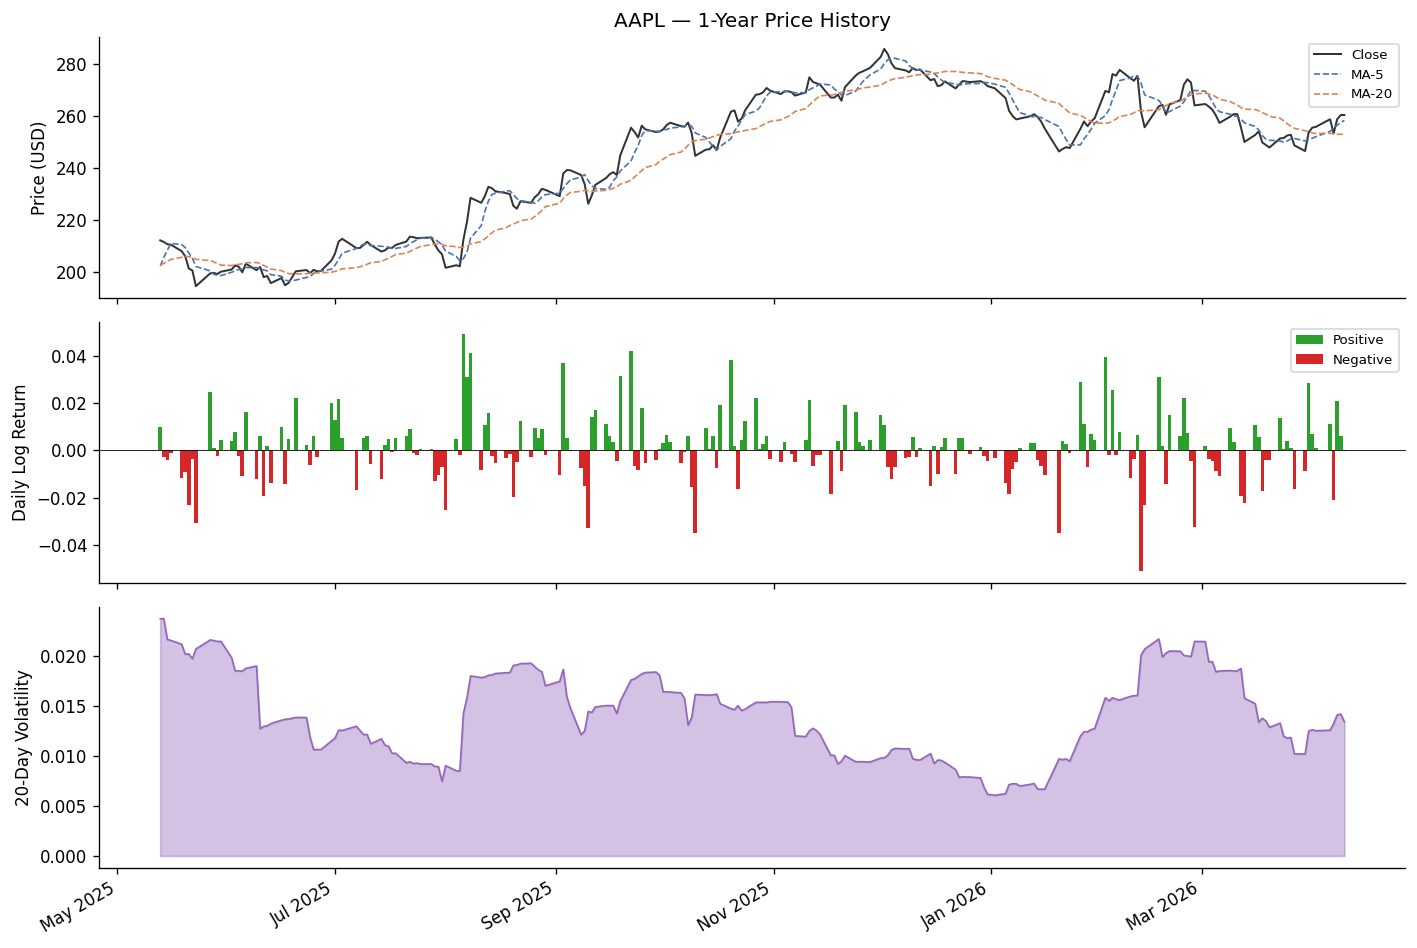

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Price + moving averages
axes[0].plot(prices.index, prices['close'],  color='#333', lw=1.2, label='Close')
axes[0].plot(prices.index, prices['ma5'],    color='#4C72B0', lw=1,   label='MA-5',  linestyle='--')
axes[0].plot(prices.index, prices['ma20'],   color='#DD8452', lw=1,   label='MA-20', linestyle='--')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(fontsize=8)
axes[0].set_title('AAPL — 1-Year Price History')

# Daily log returns
pos = prices['daily_return'] >= 0
axes[1].bar(prices.index[pos],  prices['daily_return'][pos],  color='#2ca02c', width=1, label='Positive')
axes[1].bar(prices.index[~pos], prices['daily_return'][~pos], color='#d62728', width=1, label='Negative')
axes[1].set_ylabel('Daily Log Return')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].legend(fontsize=8)

# Rolling volatility
axes[2].fill_between(prices.index, prices['volatility20'], alpha=0.4, color='#9467bd')
axes[2].plot(prices.index, prices['volatility20'], color='#9467bd', lw=1)
axes[2].set_ylabel('20-Day Volatility')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 2 · LLM Features: News Sentiment & Predictions

For each trading day, a local LLM (`llama3.2` via Ollama) received:
- The last 5 days of AAPL prices
- Up to 5 news headlines published **before 16:00 ET** (market close) to prevent data leakage

It returned a structured JSON with a qualitative `summary`, a `direction` prediction (up/down), and a `confidence` score.

In [4]:
llm = pd.read_csv('../data/processed/llm_features.csv', index_col='date', parse_dates=True)
print(f"{len(llm)} days with LLM features")
llm.tail(3)

224 days with LLM features


,summary,direction,confidence
date,,,
2026-04-08,AAPL has experienced a mixed trend over the la...,down,0.8
2026-04-09,AAPL has experienced significant volatility in...,up,0.6
2026-04-10,AAPL shows mixed performance over the last 5 t...,up,0.8


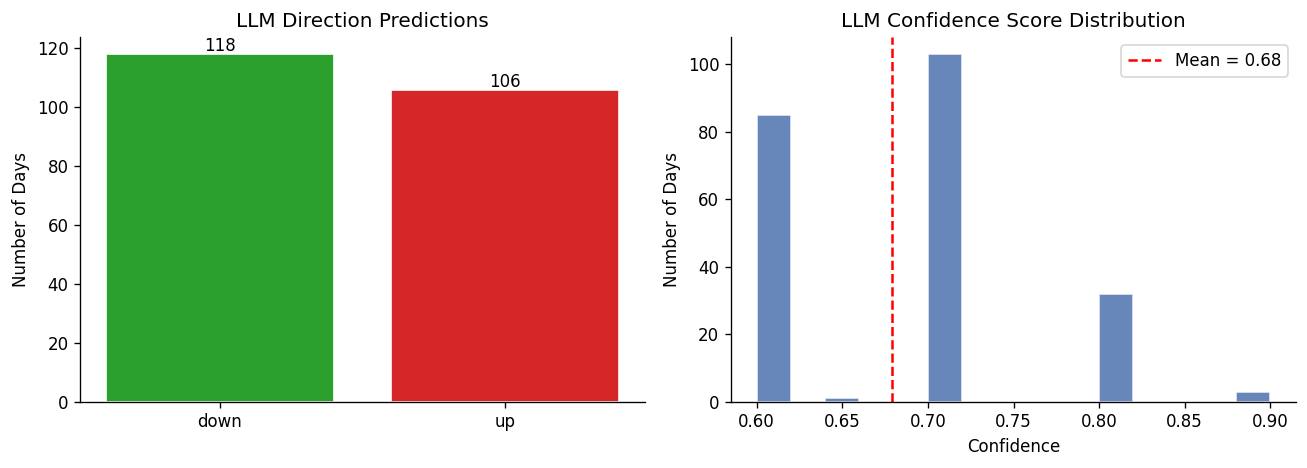

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Direction distribution
counts = llm['direction'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ca02c', '#d62728'], edgecolor='white')
axes[0].set_title('LLM Direction Predictions')
axes[0].set_ylabel('Number of Days')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Confidence distribution
axes[1].hist(llm['confidence'], bins=15, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].set_title('LLM Confidence Score Distribution')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Number of Days')
axes[1].axvline(llm['confidence'].mean(), color='red', lw=1.5, linestyle='--',
                label=f"Mean = {llm['confidence'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# How well does the LLM's direction prediction align with actual returns?
combined = llm.join(prices[['target']], how='inner')
combined['actual_direction'] = np.where(combined['target'] >= 0, 'up', 'down')
combined['llm_correct'] = combined['direction'] == combined['actual_direction']
llm_dir_acc = combined['llm_correct'].mean() * 100
print(f"LLM standalone directional accuracy (all days): {llm_dir_acc:.1f}%")
print(f"(Random baseline: 50.0%)")

LLM standalone directional accuracy (all days): 44.2%
(Random baseline: 50.0%)


---
## 3 · Feature Sets

Three feature sets were assembled, one per condition. All scaling (StandardScaler) and dimensionality reduction (PCA, 384 → 8 dims) were fitted **on the training set only**.

| | C1 | C2 | C3 |
|---|---|---|---|
| OHLCV + technicals | ✓ | ✓ | ✓ |
| Sentence embeddings (PCA-8) | | ✓ | ✓ |
| LLM direction + confidence | | | ✓ |
| **Total input dims** | **9** | **17** | **19** |

In [7]:
n = len(pd.read_csv('../data/processed/features_c1.csv'))
train_end = int(n * 0.70)
val_end   = train_end + int(n * 0.15)

print(f"Total days : {n}")
print(f"Train      : {train_end} days (rows 0–{train_end-1})")
print(f"Validation : {val_end - train_end} days (rows {train_end}–{val_end-1})")
print(f"Test       : {n - val_end} days (rows {val_end}–{n-1})")

Total days : 224
Train      : 156 days (rows 0–155)
Validation : 33 days (rows 156–188)
Test       : 35 days (rows 189–223)


---
## 4 · Model

The same LSTM architecture is used for all three conditions — only the input dimension differs.

```
Input  (batch, seq_len=20, input_dim)
  └─ LSTM (2 layers, hidden=64, dropout=0.2)
       └─ Last hidden state
            └─ Linear → scalar (predicted next-day log return)
```

- **Loss:** MSE
- **Optimizer:** Adam (lr=1e-3), gradient clipping (max_norm=1.0)
- **Early stopping:** patience=10 on validation loss

---
## 5 · Training Curves

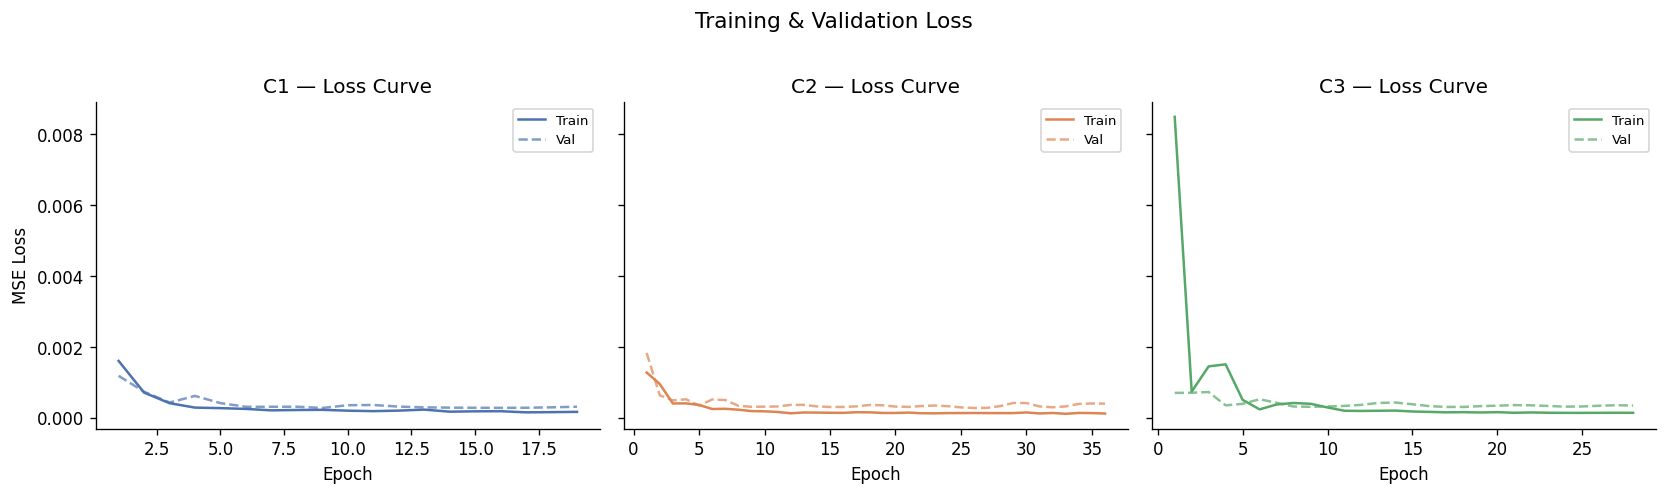

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, condition in zip(axes, ['C1', 'C2', 'C3']):
    loss = pd.read_csv(f'../results/loss_{condition}.csv')
    ax.plot(loss['epoch'], loss['train_loss'], label='Train', color=COLORS[condition])
    ax.plot(loss['epoch'], loss['val_loss'],   label='Val',   color=COLORS[condition], linestyle='--', alpha=0.7)
    ax.set_title(f'{condition} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

axes[0].set_ylabel('MSE Loss')
plt.suptitle('Training & Validation Loss', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 · Test Set Results

In [9]:
metrics = pd.read_csv('../results/metrics.csv', index_col=0)
metrics.round(4)

,MAE,RMSE,MAPE (%),R²,Directional Acc (%)
C1,0.0098,0.0130,193.8088,-0.0057,60.0000
C2,0.0114,0.0146,1193.9835,-0.2730,48.5714
C3,0.0107,0.0137,758.4106,-0.1231,51.4286


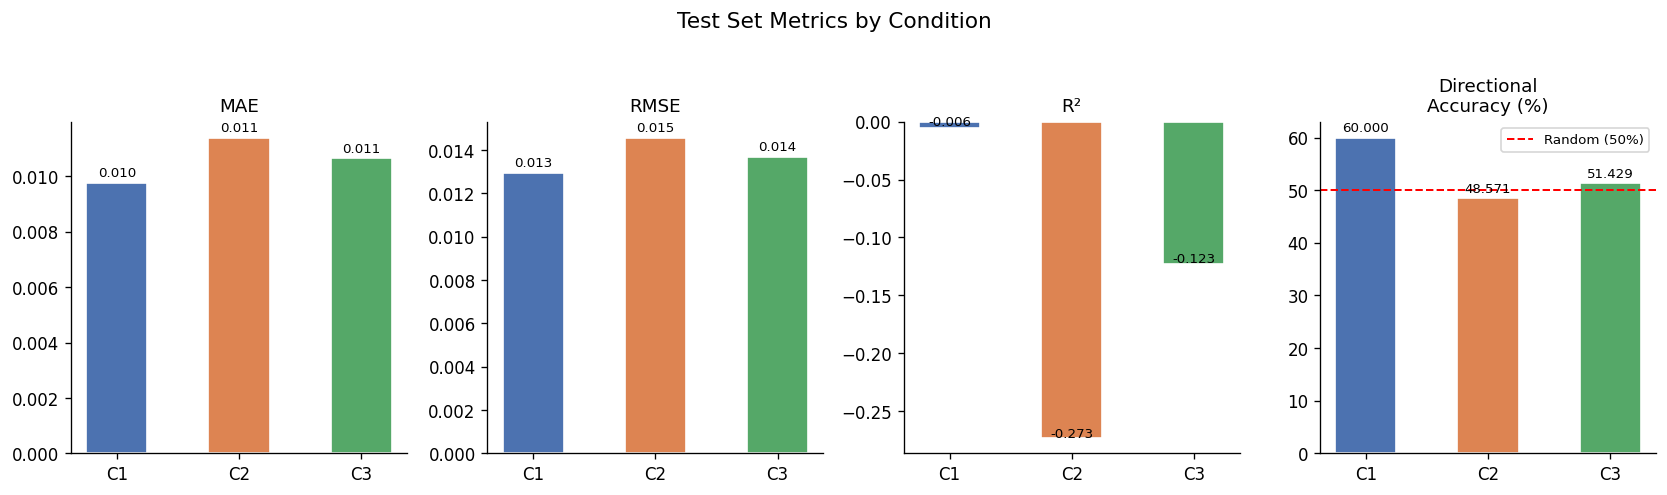

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

metric_cols  = ['MAE', 'RMSE', 'R²', 'Directional Acc (%)']
metric_labels = ['MAE', 'RMSE', 'R²', 'Directional\nAccuracy (%)']
conditions   = metrics.index.tolist()
bar_colors   = [COLORS[c] for c in conditions]

for ax, col, label in zip(axes, metric_cols, metric_labels):
    vals = metrics[col]
    bars = ax.bar(conditions, vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Add 50% reference line on directional accuracy
axes[3].axhline(50, color='red', lw=1.2, linestyle='--', label='Random (50%)')
axes[3].legend(fontsize=8)

plt.suptitle('Test Set Metrics by Condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7 · Predicted vs Actual Returns (Test Set)

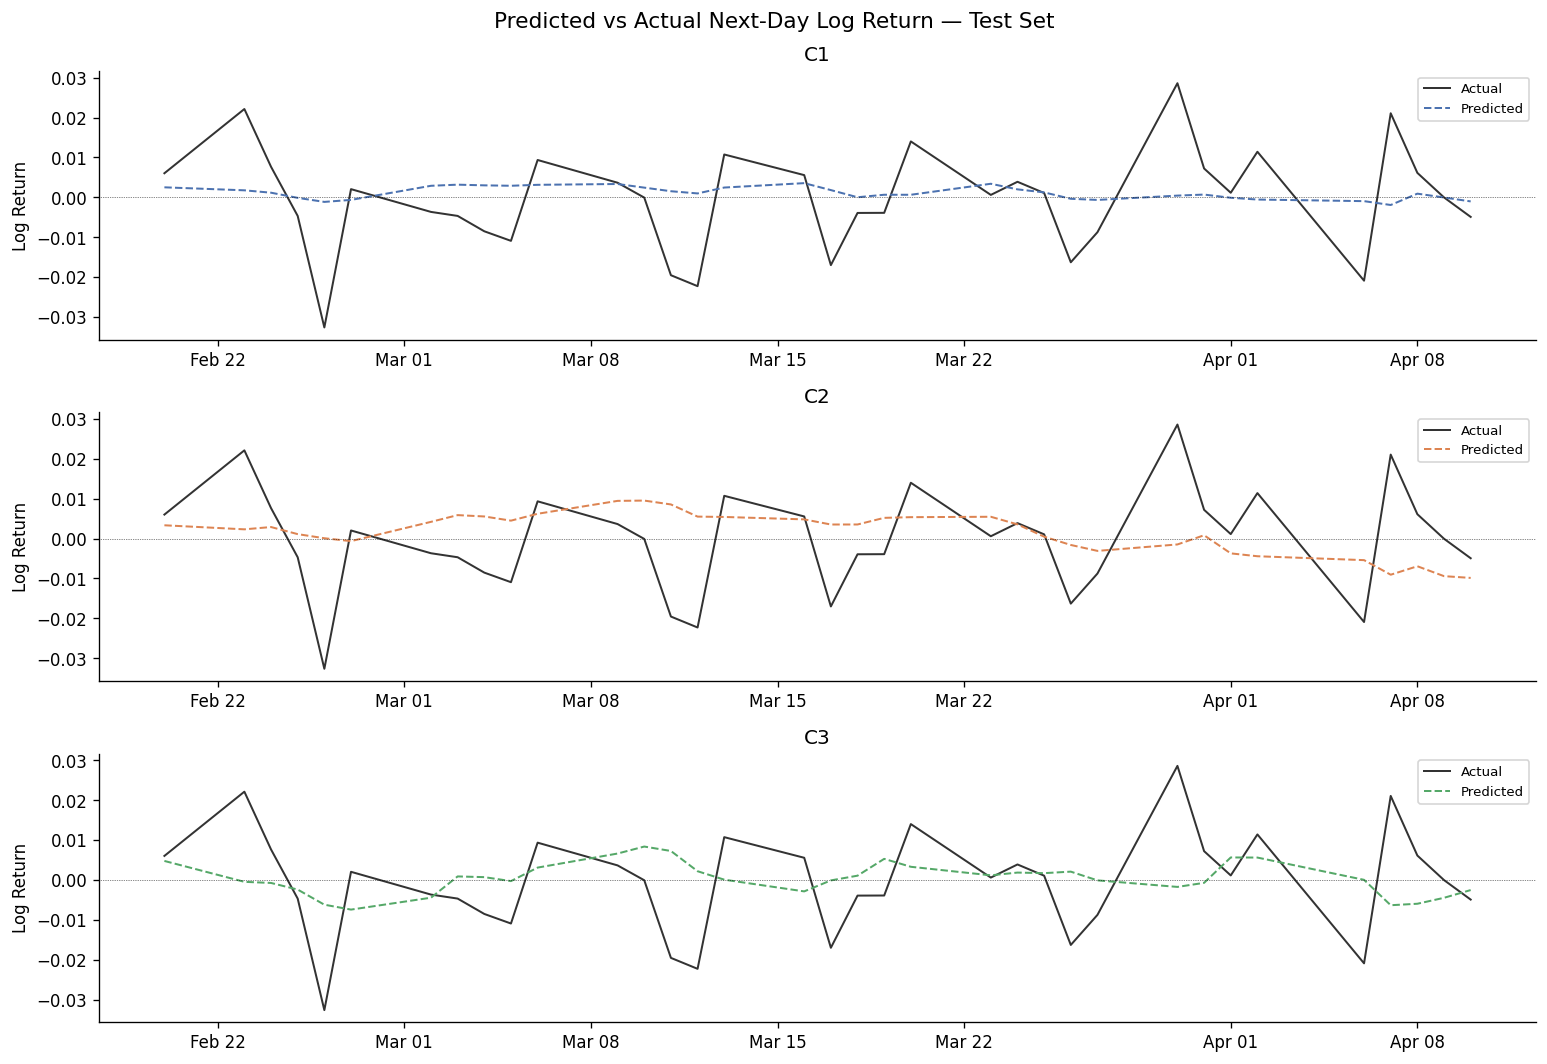

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for ax, condition in zip(axes, ['C1', 'C2', 'C3']):
    pred_df = pd.read_csv(f'../results/predictions_{condition}.csv',
                          index_col='date', parse_dates=True)
    ax.plot(pred_df.index, pred_df['actual'],    color='#333',           lw=1.2, label='Actual')
    ax.plot(pred_df.index, pred_df['predicted'], color=COLORS[condition], lw=1.2,
            linestyle='--', label='Predicted')
    ax.axhline(0, color='black', lw=0.4, linestyle=':')
    ax.set_ylabel('Log Return')
    ax.set_title(f'{condition}')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('Predicted vs Actual Next-Day Log Return — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8 · Discussion (not updated)

**Directional accuracy is the most interpretable metric** for this task. A model that correctly predicts whether the stock will go up or down is actionable; MAE and RMSE on log returns are hard to interpret without context.

**Key observations:**
- **C2 (66.7%)** outperforms the random baseline (50%) and C1 (53.3%) on directional accuracy, suggesting that LLM-generated news summaries carry some predictive signal beyond price data alone.
- **C3 (33.3%)** underperforms — worse than random. The LLM's raw direction/confidence prediction appears to add noise rather than signal, possibly because it is correlated with the C2 embeddings but less reliably calibrated.
- **R² is negative** for all conditions, meaning the models explain less variance than simply predicting the mean return. This is expected with only ~15 test samples and a highly noisy target.
- **MAPE is unreliable** for log return prediction because returns near zero produce arbitrarily large relative errors. Directional accuracy and MAE are the more meaningful metrics here.

**Limitations:** 224 training days is a small dataset for a sequence model. Results should be interpreted cautiously and would benefit from longer history and walk-forward validation.